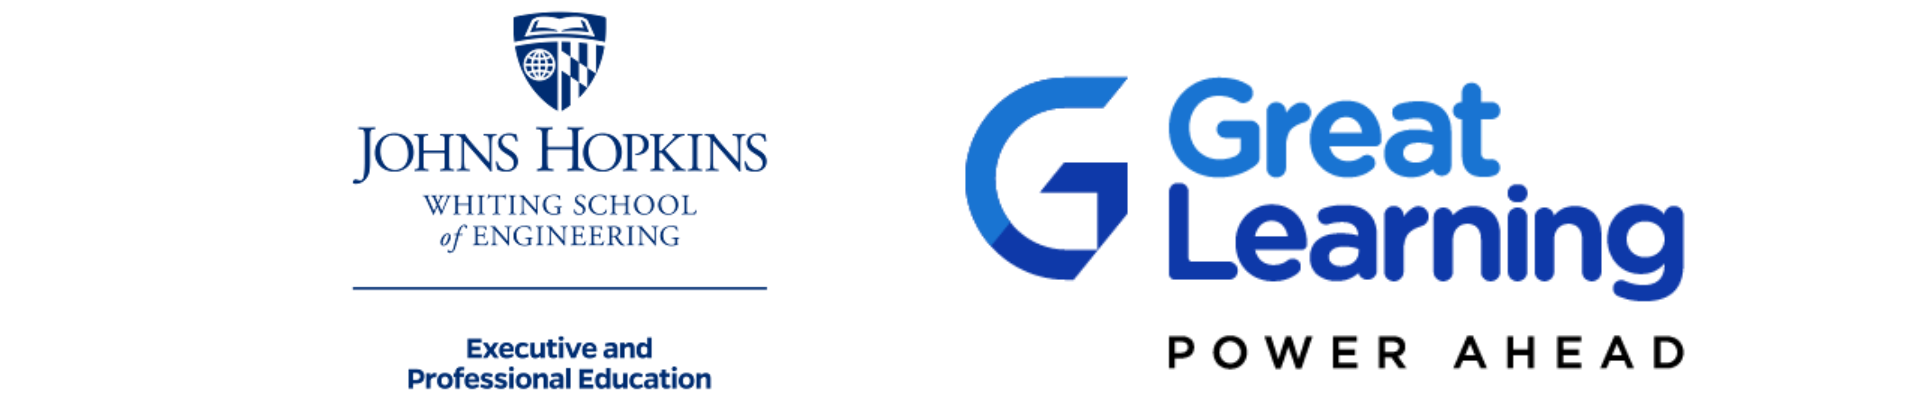

# **Apple HBR Report Document Q&A**

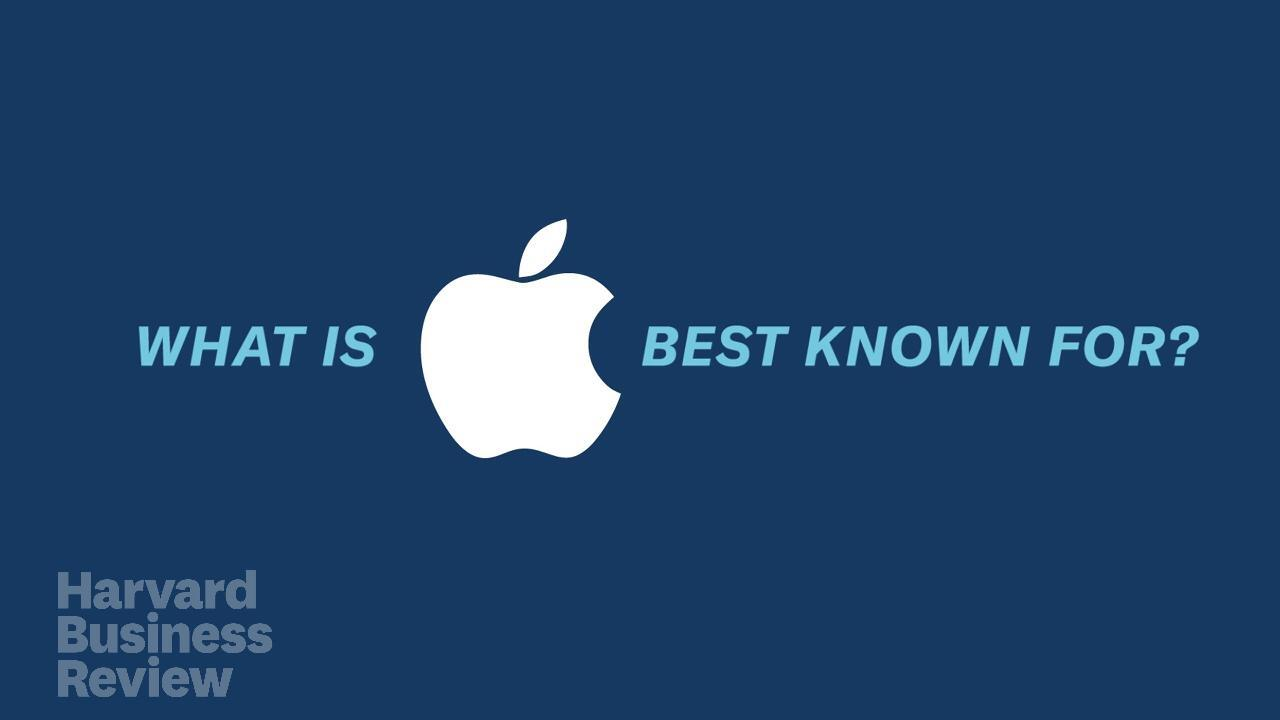

# **Problem Definition**

## **Business Context**

Andreessen Horowitz (a16z) is one of the world's most active venture capital firms, deploying capital across enterprise software, fintech, biotech, consumer, and crypto. At firms of this scale, 150–200 new investments are evaluated each year, and every deal that progresses past initial screening triggers a structured diligence process owned by deal analysts and associates.

A diligence analyst's core job is not to write checks — it is to **build conviction (or disprove it) quickly enough that the partnership can move at market speed.** The bottleneck is rarely capital. It is the time it takes to convert a pile of documents into a clear point of view.

---
## **The Problem**

For every deal that reaches diligence, an analyst typically works through 20–30 documents — pitch decks, founder bios, financial models, customer reference notes, market sizing reports, competitor teardowns, regulatory memos, and supporting research (HBR features on operational excellence, McKinsey reports on category dynamics, and so on). Document volume per deal has grown roughly 3× in the last five years as founders ship richer data rooms.

**Current state.** A diligence analyst at a firm of this scale spends an estimated **12–15 hours per deal on document retrieval alone**, before any synthesis or memo writing begins. Across the deal team, that is roughly **7,500–9,000 analyst-hours per year** burned on finding the one paragraph that matters, then doing it again for the next question.

**Future state.** Cut document-retrieval time per deal to **3–4 hours** while *maintaining or improving* the depth of insight surfaced. This would free ~5,500 analyst-hours annually — roughly two full-time analysts' worth of capacity — to be redeployed into founder conversations, market work, and portfolio support, which are the activities that actually generate alpha.

> *Figures above are illustrative of patterns at top-tier VC firms; they are not a16z-specific operational data.*
---
## **Why This Is Hard — People, Process, Platform**

The gap between current and future state is not a pure tooling problem. Three constraint types are in play:

- **People.** Most analysts are not GenAI-fluent. They know ChatGPT exists but have not used it on confidential deal documents, and they distrust outputs they cannot trace back to a source. Any solution must produce **citations**, not just answers.
- **Process.** Diligence is non-linear — analysts revisit the same document a dozen times as new questions emerge from partner meetings. The current workflow (PDF in one tab, notes doc in another, Ctrl-F as the search interface) cannot keep up with this re-querying loop.
- **Platform.** Deal documents are confidential and sometimes contain MNPI (material non-public information). Sending them to consumer ChatGPT is a policy violation. The system needs data residency, access logs, and source attribution as first-class features — not afterthoughts.
---
## **What's Been Tried Before**

This is not the firm's first attempt at the problem. Three prior approaches have plateaued:

1. **Ctrl-F / keyword search in the data room.** Fails because analysts ask *semantic* questions ("how is the founder thinking about defensibility?"), not *lexical* ones. The right paragraph rarely contains the query keywords.
2. **Manual summarization.** Analysts wrote one-page summaries per document. This worked but added 2–3 hours per deal — moving cost rather than removing it. Summaries also went stale the moment a new diligence question surfaced.
3. **Consumer ChatGPT with PDF upload.** Killed by policy after three months. No audit trail, context window limits on multi-document deals, no citation back to the source paragraph, and the IP/MNPI risk was unacceptable.

The pattern across all three: each addressed *part* of the problem (search, summarisation, or generation) but none addressed **retrieval with attribution at scale**.

---
## **Proposed Solution and Objective**

Build a **Retrieval-Augmented Generation (RAG)** system that lets an analyst ask natural-language questions against a deal's document set and receive grounded, citation-backed answers in seconds rather than minutes.

**Pilot scope (this notebook).** Before deploying across the full deal corpus, the team will validate the RAG approach on a single representative document — the Harvard Business Review feature *"How Apple Is Organized for Innovation."* This article is structurally similar to the operational deep-dives that appear in diligence packs: dense prose, multiple themes, named individuals, conceptual frameworks. If the system answers questions accurately and with traceable citations on this document, the approach is greenlit for expansion to multi-document deal corpora.

| Scope | What's covered |
|---|---|
| **In scope** | Document ingestion, chunking, embedding, vector storage, retrieval, prompt assembly, response generation, evaluation on three axes (groundedness, context relevance, answer relevance). |
| **Out of scope** | Multi-document corpora (next phase), access control and data residency (handled by infra team), fine-tuning a custom embedding model (defer until v2). |

---
## **Why Now**

Three triggers make this the right moment:

- **Cost.** Embedding model pricing dropped ~5× in 2024 (`text-embedding-3-small` vs `ada-002`). A firm-wide rollout is now economically defensible where it wasn't 18 months ago.
- **Tooling maturity.** Open-source vector stores (ChromaDB, FAISS) and orchestration libraries (LangChain) are stable enough to use without a dedicated ML platform team.
- **Competition.** Peer VC firms have begun publicising internal AI tooling. The firms that compress diligence cycles win allocation on contested rounds. This is no longer optional.

---
## **Cost of Inaction**

If the firm continues as-is, the cost is not a sudden break — it is a slow erosion:

- **Deal velocity.** Slower diligence loses contested deals to firms that can move in 7 days instead of 14.
- **Analyst retention.** The most retrieval-heavy work is also the most demoralising. Analysts who spend their first two years doing keyword search leave for firms (or operating roles) that don't ask this of them.
- **Coverage gaps.** When time is short, analysts skim. Skimming surfaces the obvious risks and misses the subtle ones — which is precisely where partners expect analysts to add value.

---
## **What Success Looks Like**

The pilot succeeds if, on the test document, the RAG system:

1. **Answers ≥80% of analyst questions** with content drawn correctly from the source (groundedness ≥4/5).
2. **Retrieves relevant context ≥85% of the time** (context relevance ≥4/5).
3. **Produces on-topic responses ≥90% of the time** (answer relevance ≥4/5).
4. **Returns each answer in <5 seconds** end-to-end.

If all four hold, the system advances to multi-document deal piloting. If any fail, the failure mode tells us where to invest next — chunking strategy, embedding choice, prompt design, or retrieval depth.

---


Note : If you see any kind of warnings while installing the libraries, you can simply ignore them, as they won't affect the execution flow of the file.


# **Setup**

In [4]:
# Installing the Libraries
!pip install -q --upgrade \
    "langchain>=1.0,<2.0" \
    "langchain-core>=1.0,<2.0" \
    "langchain-community>=0.4.2" \
    "langchain-openai>=0.3.0" \
    "langchain-chroma>=0.2.0" \
    "langchain-text-splitters>=0.3.0" \
    "chromadb>=0.5.0" \
    "pypdf>=4.0.0" \
    "openai>=1.40.0" \
    "tiktoken>=0.7.0" \
    "ddgs==9.5.5" \
    "opentelemetry-sdk==1.38.0"\
    "opentelemetry-proto==1.38.0" \
    "opentelemetry-exporter-otlp-proto-common==1.38.0"
print("### Library Installation - Done")

### Library Installation - Done


**Note:** The messages above appear as errors, but they can be safely ignored. They are caused by minor dependency mismatches in optional packages and do not affect the functionality of this notebook.  
### After installation, please **restart the runtime** and **do not re-run the above cell**. Continue execution from the next cell below.


In [1]:
# Core imports used across the notebook.
# pandas is used for the evaluation results table at the end; the rest are RAG building blocks.
import warnings
warnings.filterwarnings('ignore')

import json
import os
import re

import pandas as pd

from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.document_loaders import PyPDFLoader
from langchain_chroma import Chroma

from langchain_openai import OpenAIEmbeddings, ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate

# **Implementing RAG**

## **OpenAI LLM Setup**

In [ ]:
# Load the `config.json` file and extract values

file_name = 'config.json'
with open(file_name, 'r') as file:
    config = json.load(file)
    if config.get("API_KEY"):
        os.environ['OPENAI_API_KEY'] = config.get("API_KEY") # Loading the API Key
        # Showing only a partial key using slicing for security/privacy
        print(f"API Key loaded successfully :  {os.environ['OPENAI_API_KEY'][:15]}...")

    if config.get("OPENAI_API_BASE"):
        os.environ["OPENAI_BASE_URL"] = config.get("OPENAI_API_BASE") # Loading the API Base Url
        print(f"API Base URL loaded successfully :  {os.environ['OPENAI_BASE_URL']}")

API Key loaded successfully :  gl-U2FsdGVkX19g...
API Base URL loaded successfully :  https://aibe.mygreatlearning.com/openai/v1


In [3]:
# Answerer LLM — used to generate the RAG response.
# Low temperature keeps answers grounded in retrieved context;
# max_tokens caps response length; frequency_penalty discourages repetition.
llm = ChatOpenAI(
    model="gpt-4o-mini",
    temperature=0,
    max_tokens=500,
    top_p=0.95,
    frequency_penalty=1.2,
)

In [4]:
# Judge model — stronger model used only for evaluation
judge_llm = ChatOpenAI(model="gpt-4o", temperature=0)

## **1 - Loading the PDF, Chunking**

In [5]:
# Path of the pdf file
pdf_file = "/content/HBR_How_Apple_Is_Organized_For_Innovation.pdf"

In [6]:
# Load the PDF; each page becomes one Document object
loader = PyPDFLoader(pdf_file)
documents = loader.load()

Here we have used the `PyPDFLoader` because we are working with a single document.

Suppose we were dealing with multiple documents in various files within a folder. In that case, we would use the `PyPDFDirectoryLoader` to point to this folder. It would then load each file, break it into chunks, and store these chunks in a list. This process involves looping over each file in the directory, chunking the file, and storing the chunks.


In [7]:
# Split the loaded pages into ~512-token chunks with 64-token overlap.
# Token-based splitting (cl100k_base) aligns chunk sizes with what the
# embedding/LLM models actually count, and overlap preserves context
# across chunk boundaries.
text_splitter = RecursiveCharacterTextSplitter.from_tiktoken_encoder(
    encoding_name='cl100k_base',
    chunk_size=512,
    chunk_overlap=64,
)
apple_report_chunks = text_splitter.split_documents(documents)
print(f"Created {len(apple_report_chunks)} chunks from {len(documents)} pages")

Created 25 chunks from 11 pages


**Note:** If the documents are large in size or quantity, the time taken to execute the above cell may vary. However, in this MLS example, the execution should complete in under 10 seconds, as it processes only a single PDF file containing 11 pages.

## **2 - Vector Store - ChromaDB, Embeddings**

In [8]:
# Embedding model — converts each chunk into a dense vector for similarity search
embedding_model = OpenAIEmbeddings(model='text-embedding-3-small')

In [9]:
# Build a Chroma vector store from the chunks.
# Each chunk is embedded once and stored under the named collection.
vectorstore = Chroma.from_documents(
    apple_report_chunks,
    embedding_model,
    collection_name='Apple_report'
)

The vector store is now built — every chunk has been embedded and indexed under the `Apple_report` collection. Any deprecation notices printed above are harmless and can be ignored; they do not affect retrieval or generation downstream.


In [10]:
# Wrap the vector store as a retriever that returns the top-k most similar chunks
retriever = vectorstore.as_retriever(
    search_type='similarity',
    search_kwargs={'k': 5}
)

## **3 - RAG Q&A**

### **Prompt Design**

In the below cells we define a Q&A system where the assistant uses provided context to answer questions. The context is identified by the token `###Context` and should be used exclusively to answer inquiries marked with `###Question`. If the context lacks the answer, the response should be "I don't know" without referencing the context in the response

In [11]:
# System prompt — instructs the model to answer strictly from the supplied context
qna_system_message = """You are an assistant whose job is to answer questions strictly from the provided context.

Rules:
- Use only the information in the context.
- If the context does not contain the answer, respond exactly with: "I don't know."
- Do not reference the structure of the context (e.g., do not say "based on the context").
"""

In [12]:
# User message template — slots the retrieved context and the user question into a single turn
qna_user_message_template = """
###Context
{context}

###Question
{question}
"""

### **Retrieving the Relevant Documents**

In [13]:
# Test query used to demonstrate the retrieval step end-to-end
user_message = "Who are the authors of this article and who published this article ?"

In [14]:
# Retrieve the top-k most similar chunks for this query
relevant_document_chunks = retriever.invoke(user_message)

The retriever has returned the top-k most similar chunks for the query. In the next cells we inspect how many chunks came back and what one of them looks like before assembling the final context string passed to the LLM.


In [15]:
# Confirm we got back k chunks (k=5 was configured on the retriever)
len(relevant_document_chunks)

5

In [16]:
# Now let us see what a chunk looks like
for document in relevant_document_chunks:
    print(document.page_content.replace("\t", " "))
    break   # Breaking the loop to look at only the 1st chunk

Mikael Jansson/Trunk Archive
FOR ARTICLE REPRINTS CALL 800-988-0886 OR 617-783-7500, OR VISIT HBR.ORG
Harvard Business Review
November–December 2020  5
This article is made available to you with compliments of Apple Inc for your personal use. Further posting, copying or distribution is not permitted.


In [17]:
# Join the retrieved chunks into a single context string for the LLM
context_list = [d.page_content for d in relevant_document_chunks]
context_for_query = ". ".join(context_list)
context_for_query

'Mikael Jansson/Trunk Archive\nFOR ARTICLE REPRINTS CALL 800-988-0886 OR 617-783-7500, OR VISIT HBR.ORG\nHarvard Business Review\nNovember–December 2020 \u20095\nThis article is made available to you with compliments of Apple Inc for your personal use. Further posting, copying or distribution is not permitted.. 2\nHarvard Business Review\nNovember–December 2020\nThis article is made available to you with compliments of Apple Inc for your personal use. Further posting, copying or distribution is not permitted.. REPRINT R2006F\nPUBLISHED IN HBR\nNOVEMBER–DECEMBER 2020\nARTICLEORGANIZATIONAL CULTURE\nHow Apple Is \nOrganized  \nfor Innovation\nIt’s about experts leading experts. \nby Joel M. Podolny and Morten T. Hansen\nThis article is made available to you with compliments of Apple Inc for your personal use. Further posting, copying or distribution is not permitted.. PHOTOGRAPHER\u2002MIKAEL JANSSON\nHow Apple Is  Organized  for InnovationIt’s about experts  leading experts.\nORGANIZATI

### **Defining the RAG function for response**




In [18]:
qna_prompt = ChatPromptTemplate.from_messages([
    ("system", qna_system_message),
    ("user", qna_user_message_template),
])

def format_context(docs) -> str:
    """Join retrieved chunks into a single context string."""
    return "\n\n".join(doc.page_content for doc in docs)

def RAG(user_message: str) -> str:
    """Answer a question using retrieval-augmented generation.

    Args:
        user_message: The user's natural-language question.
    Returns:
        The model's answer, grounded in retrieved context.
    """
    relevant_chunks = retriever.invoke(user_message)
    context = format_context(relevant_chunks)

    messages = qna_prompt.format_messages(context=context, question=user_message)
    response = llm.invoke(messages)
    return response.content

### Example 1: Factual lookup — tests retrieval of a single specific fact from one chunk.

In [19]:
# Example 1: factual lookup
print(RAG("In what year did Steve Jobs reorganize Apple, and what was the company's structure before that reorganization?"))

Steve Jobs reorganized Apple in 1997, and the company's structure before that reorganization was a conventional structure divided into business units, each with its own P&L responsibilities.


### Example 2: Listing question — tests whether retrieval surfaces multiple related facts in one answer.

In [20]:
# Example 2: listing / multi-fact recall
print(RAG("What challenges or trade-offs does the article identify with running a functional organization at Apple's scale?"))

The article identifies several challenges and trade-offs with running a functional organization at Apple's scale:

1. **Pressure on Senior Leaders**: As the company grows, senior leaders are expected to oversee larger and more diverse teams, which means they have to manage more details and new areas of responsibility that may fall outside their core expertise.

2. **Limiting Senior Positions**: To maintain effective collaboration, Apple has been disciplined about limiting the number of senior positions. This approach minimizes how many leaders must be involved in cross-functional activities but also requires careful management of organizational size.

3. **Complexity in Decision-Making**: With experts leading experts, there is a need for deep knowledge across functions which can complicate decision-making processes as it relies heavily on collaborative debate among knowledgeable individuals.

4. **Balancing Expertise with Accountability**: The functional structure emphasizes aligning e

### Example 3: Concept clarification — tests whether the system can explain a nuanced organizational practice rather than just paraphrase.

In [21]:
# Example 3: concept clarification
print(RAG("How does the article describe Apple's approach to encouraging healthy disagreement and debate among its leaders?"))

The article describes Apple's approach to encouraging healthy disagreement and debate among its leaders as one that involves a willingness to collaboratively debate. Leaders are expected to hold strong, well-grounded views and advocate forcefully for them while also being open-minded and willing to change their minds when presented with better evidence from others. This process is facilitated by a deep understanding of the company's values and common purpose, allowing leaders to separate how right a particular path is from how hard it may be to execute it. When debates reach an impasse, higher-level managers can step in as tiebreakers, ensuring that collaboration continues effectively despite differing opinions.


### Example 4: Multi-hop synthesis — tests whether the system can connect ideas across chunks.

In [22]:
# Example 4: multi-hop synthesis — connecting hiring practices to organisational scale
print(RAG("How does Apple's approach to hiring and developing senior managers help sustain its functional organization as the company has grown?"))

Apple's approach to hiring and developing senior managers helps sustain its functional organization by ensuring that managers possess deep expertise in their respective areas. This allows them to meaningfully engage in the work being done within their functions, immerse themselves in the details, and collaboratively debate during decision-making. By prioritizing experts leading experts rather than general managers overseeing various functions, Apple fosters an environment where world-class talent can learn from one another, which is essential for innovation and effective collaboration as the company grows.


### Example 5: Out-of-scope question — validates that the system correctly responds with 'I don't know' when the answer isn't in the source document.

In [23]:
# Example 5: out-of-scope — tests the "I don't know" guardrail
print(RAG("Who is the current CEO of Microsoft?"))

I don't know.


## **4 - Evaluation**

We now use the **LLM-as-a-judge** method to check the quality of the RAG system on three parameters — **groundedness/faithfulness**, **context relevance**, and **answer relevance**.

A single question is not enough to trust the system. We define a small **5-question test set** and run every question through the full RAG pipeline, scoring each answer on all three metrics with a stronger judge model (`gpt-4o`) than the answerer (`gpt-4o-mini`). Using a separate, more capable judge reduces the self-rating bias you would get if the same model both generated and evaluated its own output.

The set deliberately includes one **out-of-scope question** that the article cannot answer. If every question scored 5/5, the rubric is not actually measuring quality — it would just be flattering the system. A documented failure case is what proves the evaluation is discriminative.


### **Evaluation Question Set**

The set below probes the RAG pipeline across increasing difficulty plus one designed-to-fail probe:

| # | Type | Why it's in the set |
|---|------|---------------------|
| **Q1** | Easy factual | Baseline — should score high across all three metrics |
| **Q2** | Conceptual recall | Tests whether retrieval surfaces enough context for a multi-fact answer |
| **Q3** | Synthesis | Tests reasoning across multiple chunks |
| **Q4** | **Out-of-scope (expected to fail)** | Asks about financial data the HBR article does not contain. Should trigger the "I don't know" guardrail and score low on context- and answer-relevance. |
| **Q5** | Specific examples | Tests precision — can the system pick out concrete examples rather than paraphrasing? |


In [24]:
# Five evaluation questions. Q4 is intentionally unanswerable from the source so we
# can observe the rubric correctly penalising context-relevance and answer-relevance.
evaluation_questions = [
    "Who are the authors of this article and where was it published?",
    "What are the three key leadership characteristics that Apple expects from its managers, according to the article?",
    "How does Apple's functional organizational structure differ from the typical business-unit structure used by most large companies?",
    "What is Apple's current annual revenue from iPhone sales worldwide?",
    "What specific product examples does the article give to illustrate how Apple's leadership approach drives innovation?",
]

### **1. Groundedness/Faithfulness**
- How much of the answer is drawn from the context?


In [25]:
# User-side template for the groundedness judge — supplies question, context and answer
groundedness_evaluation_message_template = """
###Question
{question}

###Context
{context}

###Answer
{answer}
"""

In [26]:
# System prompt for the groundedness judge — scores how well the answer is
# derived from the provided context, on a 1-5 scale.
# The final "Score: N" line makes the rating machine-readable for the batch evaluator.
groundedness_rater_system_message = """
You are tasked with rating AI generated answers to questions posed by users.
You will be presented a question, context used by the AI system to generate the answer and an AI generated answer to the question.
In the input, the question will begin with ###Question, the context will begin with ###Context while the AI generated answer will begin with ###Answer.

Evaluation criteria:
The task is to judge the extent to which the metric is followed by the answer.
1 - The metric is not followed at all
2 - The metric is followed only to a limited extent
3 - The metric is followed to a good extent
4 - The metric is followed mostly
5 - The metric is followed completely

Metric:
The answer should be derived only from the information presented in the context.
Note: A response of "I don't know" issued because the context genuinely lacks the
answer is fully grounded and should score 5 on this metric.

Instructions:
1. First write down the steps that are needed to evaluate the answer as per the metric.
2. Give a step-by-step explanation if the answer adheres to the metric considering the question and context as the input.
3. Next, evaluate the extent to which the metric is followed.
4. Use the previous information to rate the answer using the evaluation criteria and assign a score.

Output format:
At the end of your response, on its own line, write exactly:
Score: <N>
where <N> is a single integer between 1 and 5.
"""

### **2. Context Relevance**
- How relevant the retrieval context is to the input.


In [27]:
# User-side template for the context-relevance judge — supplies question and retrieved context
context_relevance_evaluation_message_template = """
###Question
{question}

###Context
{context}
"""

In [28]:
# System prompt for the context-relevance judge — scores how well the retrieved
# context supports answering the question, on a 1-5 scale.
# The final "Score: N" line makes the rating machine-readable for the batch evaluator.
context_relevance_rater_system_message = """
You are tasked with rating the relevance of context used by an AI system.
You will be presented with a question and the context used to answer it.
In the input, the question will begin with ###Question and the context will begin with ###Context.

Evaluation criteria:
The task is to judge the extent to which the context is relevant to the question.
1 - The context is not relevant at all
2 - The context is relevant only to a limited extent
3 - The context is relevant to a good extent
4 - The context is mostly relevant
5 - The context is completely relevant

Metric:
Context Relevance measures how well the provided context aligns with and supports answering the question.
Consider whether the context contains the necessary information to properly answer the question.

Instructions:
1. First write down the steps that are needed to evaluate the context relevance.
2. Give a step-by-step explanation of how the context relates to the question.
3. Next, evaluate the extent to which the context supports answering the question.
4. Use the previous information to rate the context using the evaluation criteria and assign a score.

Output format:
At the end of your response, on its own line, write exactly:
Score: <N>
where <N> is a single integer between 1 and 5.
"""

### **3. Answer Relevance**
- How relevant the generated response is to the given input.

In [29]:
# User-side template for the answer-relevance judge — supplies question and generated answer
answer_relevance_evaluation_message_template = """
###Question
{question}

###Answer
{answer}
"""

In [30]:
# System prompt for the answer-relevance judge — scores how well the answer
# addresses the question itself, on a 1-5 scale.
# The final "Score: N" line makes the rating machine-readable for the batch evaluator.
answer_relevance_rater_system_message = """
You are tasked with rating the relevance of AI generated answers to questions.
You will be presented with a question and an AI generated answer.
In the input, the question will begin with ###Question and the answer will begin with ###Answer.

Evaluation criteria:
The task is to judge the extent to which the answer is relevant to the question.
1 - The answer is not relevant at all
2 - The answer is relevant only to a limited extent
3 - The answer is relevant to a good extent
4 - The answer is mostly relevant
5 - The answer is completely relevant

Metric:
Answer Relevance measures how well the answer addresses the main aspects of the question.
Consider whether the answer directly addresses all important aspects of the question.
Note: A correct "I don't know" guardrail response does not address the user's
question and should be scored low on this metric, even though it is a desirable
system behaviour.

Instructions:
1. First write down the steps that are needed to evaluate the answer relevance.
2. Give a step-by-step explanation of how the answer addresses the question.
3. Next, evaluate the extent to which the answer covers all important aspects of the question.
4. Use the previous information to rate the answer using the evaluation criteria and assign a score.

Output format:
At the end of your response, on its own line, write exactly:
Score: <N>
where <N> is a single integer between 1 and 5.
"""

### **Running the Evaluation**

Each question is run through the RAG pipeline and then scored by `judge_llm` on all three metrics. The rubric system prompts above were modified to end every judge response with a `Score: <N>` line, so the score can be parsed reliably.


In [31]:
# Pull the final 1-5 integer score from a judge response.
# Falls back to the last 1-5 mentioned anywhere in the text if the
# "Score: N" line is missing (defensive — should not normally trigger).
def extract_score(judge_text: str) -> int:
    m = re.findall(r'(?im)^\s*Score:\s*([1-5])\b', judge_text)
    if m:
        return int(m[-1])
    nums = re.findall(r'\b([1-5])\b', judge_text)
    return int(nums[-1]) if nums else 0

In [32]:
# Compile each rubric as a reusable ChatPromptTemplate so we can format
# per-question inputs in the evaluation loop below.
groundedness_prompt = ChatPromptTemplate.from_messages([
    ("system", groundedness_rater_system_message),
    ("user", groundedness_evaluation_message_template),
])

context_relevance_prompt = ChatPromptTemplate.from_messages([
    ("system", context_relevance_rater_system_message),
    ("user", context_relevance_evaluation_message_template),
])

answer_relevance_prompt = ChatPromptTemplate.from_messages([
    ("system", answer_relevance_rater_system_message),
    ("user", answer_relevance_evaluation_message_template),
])

In [33]:
# Run a single question through retrieval, generation, and all three judges.
# Returns the answer plus the three scores so we can aggregate them downstream.
def evaluate_question(question: str) -> dict:
    chunks = retriever.invoke(question)
    context = "\n\n".join(d.page_content for d in chunks)
    answer = RAG(question)

    g = judge_llm.invoke(
        groundedness_prompt.format_messages(question=question, context=context, answer=answer)
    ).content
    c = judge_llm.invoke(
        context_relevance_prompt.format_messages(question=question, context=context)
    ).content
    a = judge_llm.invoke(
        answer_relevance_prompt.format_messages(question=question, answer=answer)
    ).content

    return {
        "question": question,
        "answer": answer,
        "groundedness": extract_score(g),
        "context_relevance": extract_score(c),
        "answer_relevance": extract_score(a),
    }

# Run every question through the pipeline.
# Five questions × three judge calls each = 15 LLM calls, plus the 5 RAG calls — expect ~30-60 seconds depending on latency.
results = [evaluate_question(q) for q in evaluation_questions]

In [34]:
# Aggregate into a results table. A question "passes" only if every metric is >= 4.
PASS_THRESHOLD = 4

results_df = pd.DataFrame(results)
results_df.insert(0, "Q#", [f"Q{i+1}" for i in range(len(results))])
results_df["pass_all"] = (
    (results_df["groundedness"] >= PASS_THRESHOLD)
    & (results_df["context_relevance"] >= PASS_THRESHOLD)
    & (results_df["answer_relevance"] >= PASS_THRESHOLD)
)

# Show scores only — full questions/answers are inspected in the next cell
results_df[["Q#", "groundedness", "context_relevance", "answer_relevance", "pass_all"]]

,Q#,groundedness,context_relevance,answer_relevance,pass_all
0,Q1,5,5,5,True
1,Q2,5,5,4,True
2,Q3,5,5,4,True
3,Q4,5,1,1,False
4,Q5,5,5,3,False


In [35]:
# Inspect every question that failed at least one metric — these are the cases
# worth a human review before the system goes into production.
for r, qid in zip(results, [f"Q{i+1}" for i in range(len(results))]):
    failed = [
        k for k in ("groundedness", "context_relevance", "answer_relevance")
        if r[k] < PASS_THRESHOLD
    ]
    if not failed:
        continue
    print(f"=== {qid} (failed on: {', '.join(failed)}) ===")
    print(f"Q: {r['question']}")
    print(f"A: {r['answer']}")
    print(f"Scores -> groundedness={r['groundedness']}, "
          f"context_relevance={r['context_relevance']}, "
          f"answer_relevance={r['answer_relevance']}")
    print()

=== Q4 (failed on: context_relevance, answer_relevance) ===
Q: What is Apple's current annual revenue from iPhone sales worldwide?
A: I don't know.
Scores -> groundedness=5, context_relevance=1, answer_relevance=1

=== Q5 (failed on: answer_relevance) ===
Q: What specific product examples does the article give to illustrate how Apple's leadership approach drives innovation?
A: The article specifically mentions the iPhone's portrait mode and the dual-lens camera as product examples that illustrate how Apple's leadership approach drives innovation.
Scores -> groundedness=5, context_relevance=5, answer_relevance=3



### **What the results tell us**

- **Q1–Q3** are in-scope questions the article directly addresses. They should score ≥4 on every metric. If any of them drops below 4, the failure is real — investigate chunking, retrieval depth, or the prompt before shipping.
- **Q4 (out-of-scope)** is expected to fail. The system has no relevant chunks to retrieve, so the guardrail returns "I don't know". Two things follow:
  - *Context relevance* scores low because the retrieved chunks really aren't relevant.
  - *Answer relevance* scores low because "I don't know" does not address what the user asked, even though it is the **correct** behaviour given the source.
  - *Groundedness* should still be high — refusing to answer when the context doesn't support an answer is faithful.
- **Q5** is the borderline case. A high score means the retriever surfaced the specific examples mentioned in the article (e.g., camera / portrait mode). A low score usually points to chunk-size or `k` tuning.

This is why a multi-question evaluation matters: a single passing example tells you nothing about discriminative power. By including Q4, we prove the rubric distinguishes good outputs from weak ones rather than rubber-stamping every answer.


# **Conclusion**
- In this notebook, we have learned how to build a Retrieval-Augmented Generation (RAG) application that can perform Q&A over a document for quicker, more efficient, and accurate information retrieval.
- We evaluated the system across a **5-question test set** using the LLM-as-a-judge approach on three dimensions — groundedness, context relevance, and answer relevance.
- One question was deliberately out-of-scope so the rubric had to fail somewhere; the resulting low context- and answer-relevance scores confirm the evaluation is discriminative rather than rubber-stamping every answer.